# Syria Campaign — Donation Anomaly Detection
**Adapted from: Bank Transaction Fraud Detection (LOL Bank Pvt. Ltd. Kaggle Dataset)**

---

## Background & Domain Mapping

This notebook adapts a bank transaction fraud detection project to the problem of **detecting anomalous or potentially bad-actor donations** in a humanitarian campaign context (e.g. the Syria Campaign).

The original dataset models bank transactions; the table below documents how each column maps conceptually to the donation domain:

| Original Column | Donation Equivalent | Notes |
|---|---|---|
| `Customer_ID` | `Donor_ID` | Unique identifier per donor |
| `Customer_Name` | `Donor_Name` | May be pseudonymous or anon |
| `Gender` | `Gender` | Retained |
| `Age` | `Age` | Retained |
| `State` / `City` | `Region` / `City` | Donor geography |
| `Account_Type` | `Donation_Channel` | e.g. Online, Direct, Recurring |
| `Transaction_Amount` | `Donation_Amount` | Core signal |
| `Transaction_Type` | `Donation_Type` | e.g. One-off, Recurring, Refund |
| `Merchant_Category` | `Campaign_Category` | e.g. Emergency Relief, Medical |
| `Account_Balance` | `Cumulative_Given` | Rolling total donated by donor |
| `Transaction_Device` | `Donation_Platform` | e.g. Mobile, Web, Bank Transfer |
| `Transaction_Location` | `Donation_Location` | Retained |
| `Is_Fraud` | `Is_Anomalous` | 1 = suspicious/bad-actor donation |
| `Transaction_Currency` | `Currency` | Multi-currency donations common |

### What counts as an 'anomalous' donation in this context?
Unlike bank fraud, the threat model for a humanitarian campaign includes:
- **Money laundering via charity** — large donations quickly followed by refund requests
- **Coordinated small-amount donations** from many accounts sharing identifiers (email domain, IP region, device)
- **Sanctions evasion** — donations from restricted geographies or entities
- **Reputational risk donors** — politically motivated actors seeking association with the campaign
- **Structuring** — splitting large donations into many small ones to avoid reporting thresholds

The `Is_Fraud` label in this dataset serves as a **proxy** for `Is_Anomalous`. In production, labels would be derived from compliance review outcomes.

---
## 0. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    RocCurveDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
FRAUD_COLOR = "#e74c3c"
LEGIT_COLOR = "#2980b9"

---
## 1. Load & Rename Data

We load the original bank transaction dataset and immediately rename columns to the donation domain vocabulary.

In [2]:
# Adjust path as needed
RAW_PATH = "Bank_Transaction_Fraud_Detection.csv"

raw_df = pd.read_csv(RAW_PATH)

# Domain remapping
COLUMN_MAP = {
    "Customer_ID": "Donor_ID",
    "Customer_Name": "Donor_Name",
    "Gender": "Gender",
    "Age": "Age",
    "State": "Region",
    "City": "City",
    "Bank_Branch": "Donation_Branch",
    "Account_Type": "Donation_Channel",
    "Transaction_ID": "Donation_ID",
    "Transaction_Date": "Donation_Date",
    "Transaction_Time": "Donation_Time",
    "Transaction_Amount": "Donation_Amount",
    "Merchant_ID": "Campaign_ID",
    "Transaction_Type": "Donation_Type",
    "Merchant_Category": "Campaign_Category",
    "Account_Balance": "Cumulative_Given",
    "Transaction_Device": "Donation_Platform",
    "Transaction_Location": "Donation_Location",
    "Device_Type": "Device_Type",
    "Is_Fraud": "Is_Anomalous",
    "Transaction_Currency": "Currency",
    "Customer_Contact": "Donor_Contact",
    "Transaction_Description": "Donation_Description",
    "Customer_Email": "Donor_Email",
}

df = raw_df.rename(columns=COLUMN_MAP).copy()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200000, 24)


,Donor_ID,Donor_Name,Gender,Age,Region,City,Donation_Branch,Donation_Channel,Donation_ID,Donation_Date,Donation_Time,Donation_Amount,Campaign_ID,Donation_Type,Campaign_Category,Cumulative_Given,Donation_Platform,Donation_Location,Device_Type,Is_Anomalous,Currency,Donor_Contact,Donation_Description,Donor_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,16:04:07,32415.45,214e03c5-5c34-40d1-a66c-f440aa2bbd02,Transfer,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,17:14:53,43622.60,f9e3f11f-28d3-4199-b0ca-f225a155ede6,Bill Payment,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,03:09:52,63062.56,97977d83-5486-4510-af1c-8dada3e1cfa0,Bill Payment,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,12:27:02,14000.72,f45cd6b3-5092-44d0-8afb-490894605184,Debit,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,18:30:46,18335.16,70dd77dd-3b00-4b2c-8ebc-cfb8af5f6741,Transfer,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


---
## 2. Understanding the Data (EDA)

### 2.1 Basic Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Donor_ID              200000 non-null  str    
 1   Donor_Name            200000 non-null  str    
 2   Gender                200000 non-null  str    
 3   Age                   200000 non-null  int64  
 4   Region                200000 non-null  str    
 5   City                  200000 non-null  str    
 6   Donation_Branch       200000 non-null  str    
 7   Donation_Channel      200000 non-null  str    
 8   Donation_ID           200000 non-null  str    
 9   Donation_Date         200000 non-null  str    
 10  Donation_Time         200000 non-null  str    
 11  Donation_Amount       200000 non-null  float64
 12  Campaign_ID           200000 non-null  str    
 13  Donation_Type         200000 non-null  str    
 14  Campaign_Category     200000 non-null  str    
 15  Cumulative_

In [4]:
"""
Key observations from the original bank dataset (carried over):
- 200,000 rows, 24 columns, no missing values.
- Age range 18–70, mean ~44.
- Donation_Amount (Transaction_Amount): mean ~49,538 INR, normal-ish distribution.
- Cumulative_Given (Account_Balance): mean ~52,438 INR.
- Is_Anomalous rate: ~5.04% (10,088 anomalous out of 200,000).

In the donation context: the 5% 'anomalous' rate is a useful proxy but
real-world campaign anomaly rates would likely be 0.5–2%. The class
imbalance handling below is therefore especially important.
"""

df.describe()

,Age,Donation_Amount,Cumulative_Given,Is_Anomalous
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


In [5]:
df.describe(include="object")

,Donor_ID,Donor_Name,Gender,Region,City,Donation_Branch,Donation_Channel,Donation_ID,Donation_Date,Donation_Time,Campaign_ID,Donation_Type,Campaign_Category,Donation_Platform,Donation_Location,Device_Type,Currency,Donor_Contact,Donation_Description,Donor_Email
count,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000
unique,200000,142699,2,34,145,145,3,200000,31,77856,200000,5,6,20,148,4,1,9000,172,4779
top,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Aahana Kala,Male,Nagaland,Chandigarh,Chandigarh Branch,Checking,4fa3208f-9e23-42dc-b330-844829d0c12c,29-01-2025,13:02:29,214e03c5-5c34-40d1-a66c-f440aa2bbd02,Credit,Restaurant,Self-service Banking Machine,"Kavaratti, Lakshadweep",POS,INR,+9191471XXXXXX,Sports ticket,krishnaXXX@XXXXX.com
freq,1,8,100452,6031,8135,8135,66924,1,6854,11,1,40180,33525,21707,5954,50111,200000,41,1268,99


In [6]:
print("Missing values:")
df.isna().sum()[df.isna().sum() > 0]

Missing values:


Series([], dtype: int64)

### 2.2 Class Balance (Anomalous vs. Legitimate)

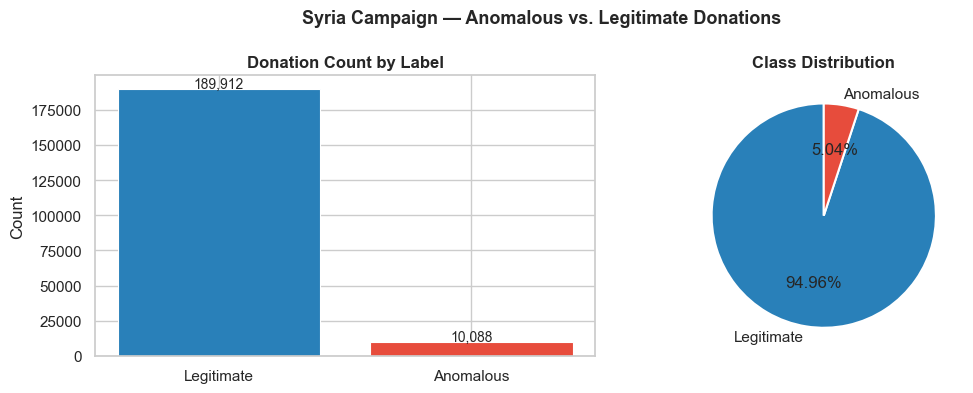


Anomalous rate: 5.04%
Note: Class imbalance will be handled via class_weight='balanced' and SMOTE.


In [7]:
anomaly_counts = df["Is_Anomalous"].value_counts()
labels = ["Legitimate", "Anomalous"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(
    labels,
    anomaly_counts.values,
    color=[LEGIT_COLOR, FRAUD_COLOR],
    edgecolor="white",
    linewidth=0.8,
)
axes[0].set_title("Donation Count by Label", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(anomaly_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(
    anomaly_counts.values,
    labels=labels,
    autopct="%1.2f%%",
    colors=[LEGIT_COLOR, FRAUD_COLOR],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Class Distribution", fontweight="bold")

plt.suptitle(
    "Syria Campaign — Anomalous vs. Legitimate Donations",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\nAnomalous rate: {anomaly_counts[1]/len(df):.2%}")
print("Note: Class imbalance will be handled via class_weight='balanced' and SMOTE.")

### 2.3 Donation Amount Distribution

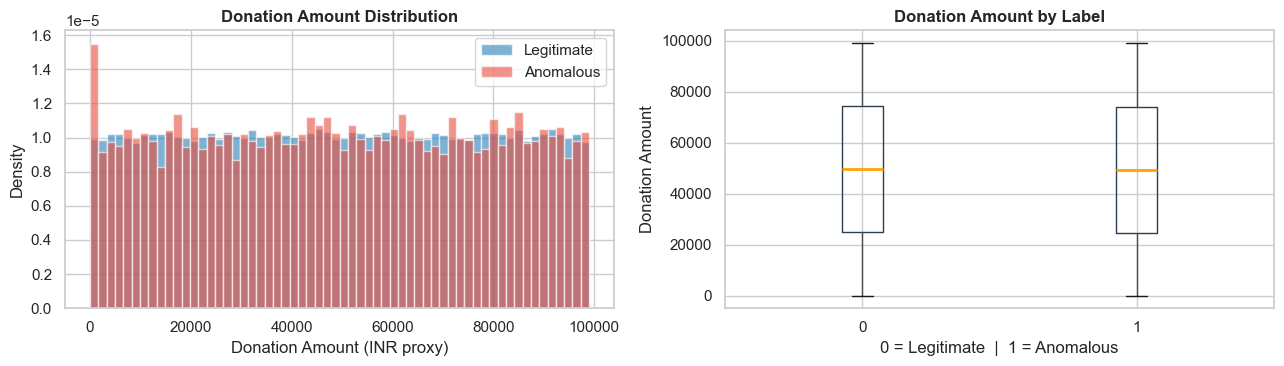


Donation Amount by label:


,count,mean,std,min,25%,50%,75%,max
Is_Anomalous,,,,,,,,
0,189912.0,49551.83,28541.88,10.29,24877.68,49517.42,74326.87,98999.98
1,10088.0,49277.93,28739.52,10.41,24420.04,49162.94,74068.72,98999.02


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [
    (0, LEGIT_COLOR, "Legitimate"),
    (1, FRAUD_COLOR, "Anomalous"),
]:
    subset = df[df["Is_Anomalous"] == label]["Donation_Amount"]
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)

axes[0].set_title("Donation Amount Distribution", fontweight="bold")
axes[0].set_xlabel("Donation Amount (INR proxy)")
axes[0].set_ylabel("Density")
axes[0].legend()

df.boxplot(
    column="Donation_Amount",
    by="Is_Anomalous",
    ax=axes[1],
    boxprops=dict(color="#2c3e50"),
    medianprops=dict(color="orange", linewidth=2),
)
axes[1].set_title("Donation Amount by Label", fontweight="bold")
axes[1].set_xlabel("0 = Legitimate  |  1 = Anomalous")
axes[1].set_ylabel("Donation Amount")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("\nDonation Amount by label:")
df.groupby("Is_Anomalous")["Donation_Amount"].describe().round(2)

### 2.4 Categorical Breakdown — Anomaly Rate by Category

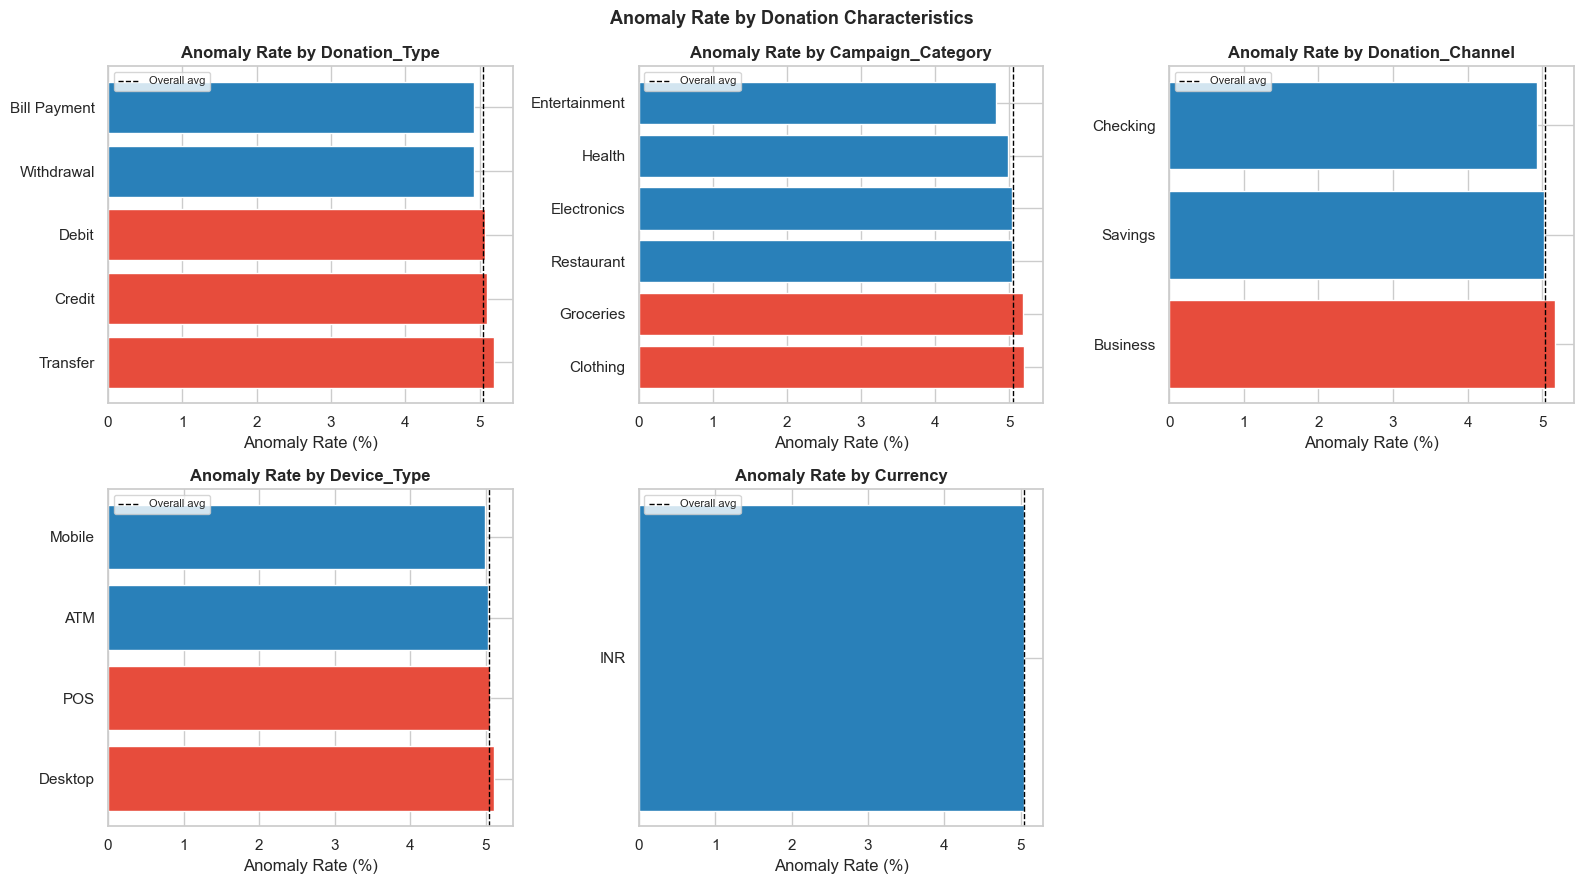

In [9]:
CAT_COLS = [
    "Donation_Type",
    "Campaign_Category",
    "Donation_Channel",
    "Device_Type",
    "Currency",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    rates = df.groupby(col)["Is_Anomalous"].mean().sort_values(ascending=False)
    axes[i].barh(
        rates.index,
        rates.values * 100,
        color=[
            FRAUD_COLOR if v > df["Is_Anomalous"].mean() else LEGIT_COLOR
            for v in rates.values
        ],
    )
    axes[i].axvline(
        df["Is_Anomalous"].mean() * 100,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Overall avg",
    )
    axes[i].set_title(f"Anomaly Rate by {col}", fontweight="bold")
    axes[i].set_xlabel("Anomaly Rate (%)")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Anomaly Rate by Donation Characteristics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.5 Temporal Patterns

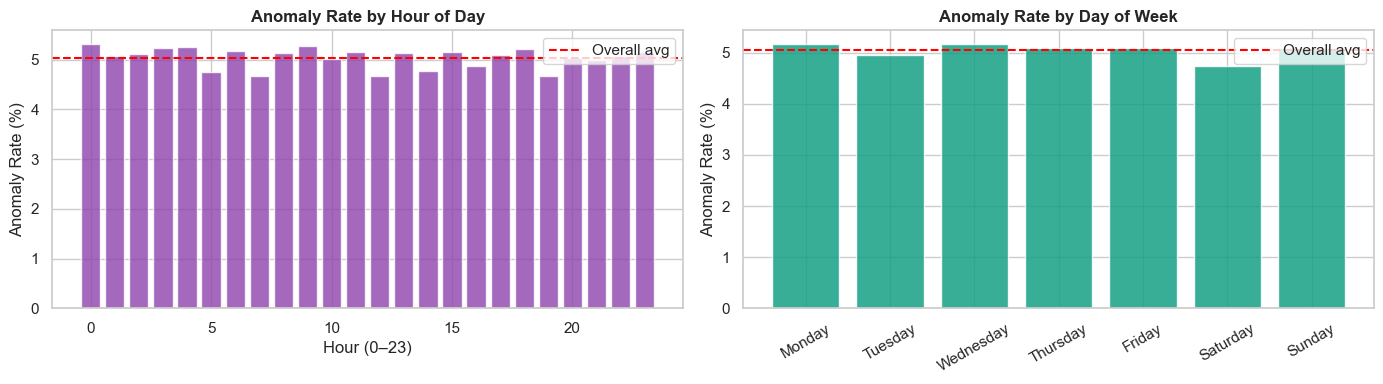


Campaign-domain insight: Anomalies clustering at odd hours (e.g., 2–5am) may
indicate automated bot donations or actors in different time zones.


In [10]:
df["Donation_Date"] = pd.to_datetime(df["Donation_Date"])
df["Hour"] = pd.to_datetime(
    df["Donation_Time"], format="%H:%M:%S", errors="coerce"
).dt.hour
df["DayOfWeek"] = df["Donation_Date"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Anomaly rate by hour
hourly = df.groupby("Hour")["Is_Anomalous"].mean()
axes[0].bar(hourly.index, hourly.values * 100, color="#8e44ad", alpha=0.8)
axes[0].axhline(
    df["Is_Anomalous"].mean() * 100, color="red", linestyle="--", label="Overall avg"
)
axes[0].set_title("Anomaly Rate by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Anomaly Rate (%)")
axes[0].legend()

# Donation volume by day
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
daily = df.groupby("DayOfWeek")["Is_Anomalous"].agg(["sum", "count"])
daily = daily.reindex([d for d in day_order if d in daily.index])
daily["rate"] = daily["sum"] / daily["count"] * 100
axes[1].bar(daily.index, daily["rate"], color="#16a085", alpha=0.85)
axes[1].axhline(
    df["Is_Anomalous"].mean() * 100, color="red", linestyle="--", label="Overall avg"
)
axes[1].set_title("Anomaly Rate by Day of Week", fontweight="bold")
axes[1].set_ylabel("Anomaly Rate (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nCampaign-domain insight: Anomalies clustering at odd hours (e.g., 2–5am) may")
print("indicate automated bot donations or actors in different time zones.")

### 2.6 Geographic Risk (Regional Anomaly Rates)

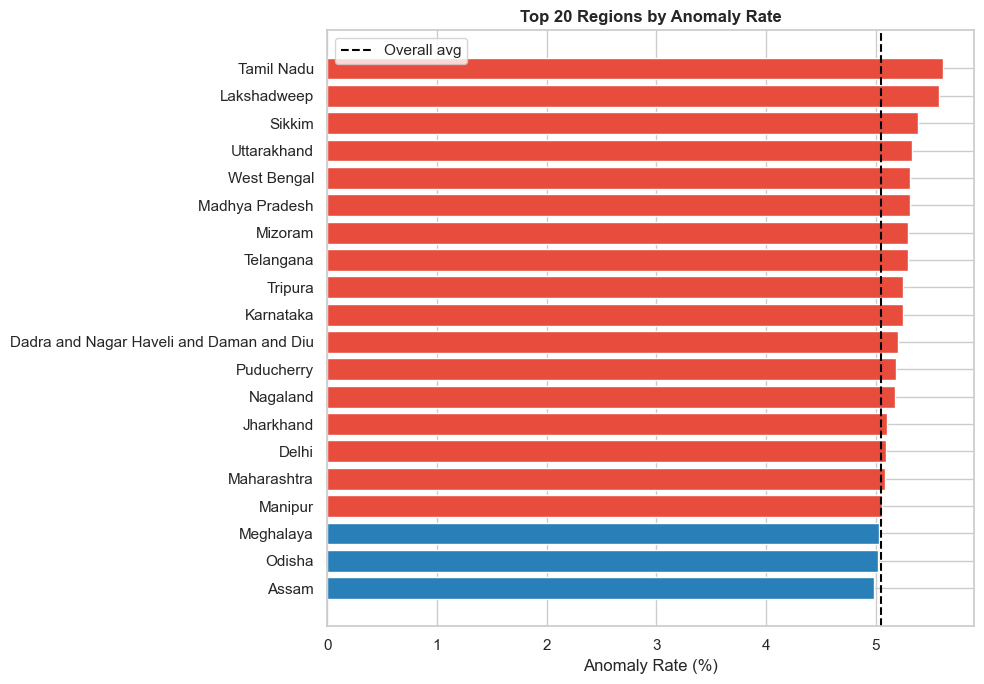


Campaign note: In a real deployment, high-anomaly regions would be cross-referenced
against OFAC/UN sanctions lists before automatic flagging.


In [11]:
regional_rates = (
    df.groupby("Region")["Is_Anomalous"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Anomaly_Rate", "count": "Donation_Count"})
    .sort_values("Anomaly_Rate", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    FRAUD_COLOR if r > df["Is_Anomalous"].mean() else LEGIT_COLOR
    for r in regional_rates["Anomaly_Rate"]
]
ax.barh(regional_rates.index, regional_rates["Anomaly_Rate"] * 100, color=colors)
ax.axvline(
    df["Is_Anomalous"].mean() * 100, linestyle="--", color="black", label="Overall avg"
)
ax.set_title("Top 20 Regions by Anomaly Rate", fontweight="bold")
ax.set_xlabel("Anomaly Rate (%)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(
    "\nCampaign note: In a real deployment, high-anomaly regions would be cross-referenced"
)
print("against OFAC/UN sanctions lists before automatic flagging.")

---
## 3. Campaign-Specific Feature Engineering

These features capture patterns relevant to donation anomaly detection that do not exist in the original bank fraud framing.

In [12]:
feat_df = df.copy()

# ── Temporal features ──────────────────────────────────────────────────────
feat_df["Is_Night_Donation"] = (feat_df["Hour"].between(0, 5)).astype(int)
feat_df["Is_Weekend"] = feat_df["DayOfWeek"].isin(["Saturday", "Sunday"]).astype(int)
feat_df["Is_Business_Hours"] = (feat_df["Hour"].between(9, 17)).astype(int)

# ── Amount-based features ──────────────────────────────────────────────────
# Round-number donations are a classic structuring indicator
feat_df["Is_Round_Amount"] = (feat_df["Donation_Amount"] % 100 == 0).astype(int)

# Donation as fraction of cumulative giving — sudden large donation vs. history
feat_df["Amount_to_Cumulative_Ratio"] = feat_df["Donation_Amount"] / (
    feat_df["Cumulative_Given"] + 1
)

# Log-transform for skew reduction
feat_df["Log_Donation_Amount"] = np.log1p(feat_df["Donation_Amount"])
feat_df["Log_Cumulative_Given"] = np.log1p(feat_df["Cumulative_Given"])

# Z-score of donation amount (donor-level would require groupby; using global here)
feat_df["Amount_Zscore"] = stats.zscore(feat_df["Donation_Amount"])

# ── Donor-level aggregated risk signals ────────────────────────────────────
donor_stats = (
    feat_df.groupby("Donor_ID")
    .agg(
        Donor_Donation_Count=("Donation_Amount", "count"),
        Donor_Mean_Amount=("Donation_Amount", "mean"),
        Donor_Std_Amount=("Donation_Amount", "std"),
        Donor_Max_Amount=("Donation_Amount", "max"),
        Donor_Unique_Campaigns=("Campaign_ID", "nunique"),
        Donor_Unique_Devices=("Donation_Platform", "nunique"),
    )
    .reset_index()
)
donor_stats["Donor_Std_Amount"] = donor_stats["Donor_Std_Amount"].fillna(0)
feat_df = feat_df.merge(donor_stats, on="Donor_ID", how="left")

# Deviation of this donation from donor's own mean — key signal for outlier gifts
feat_df["Amount_Deviation_from_Donor_Mean"] = (
    feat_df["Donation_Amount"] - feat_df["Donor_Mean_Amount"]
) / (feat_df["Donor_Std_Amount"] + 1)

# ── Platform risk: anonymous/digital channels ──────────────────────────────
HIGH_RISK_PLATFORMS = ["Virtual Card", "QR Code Scanner", "Banking Chatbot"]
feat_df["High_Risk_Platform"] = (
    feat_df["Donation_Platform"].isin(HIGH_RISK_PLATFORMS).astype(int)
)

print("New features added:")
new_feats = [
    "Is_Night_Donation",
    "Is_Weekend",
    "Is_Business_Hours",
    "Is_Round_Amount",
    "Amount_to_Cumulative_Ratio",
    "Log_Donation_Amount",
    "Log_Cumulative_Given",
    "Amount_Zscore",
    "Donor_Donation_Count",
    "Donor_Mean_Amount",
    "Donor_Std_Amount",
    "Donor_Max_Amount",
    "Donor_Unique_Campaigns",
    "Donor_Unique_Devices",
    "Amount_Deviation_from_Donor_Mean",
    "High_Risk_Platform",
]
print(new_feats)
feat_df[new_feats].describe().round(3)

New features added:
['Is_Night_Donation', 'Is_Weekend', 'Is_Business_Hours', 'Is_Round_Amount', 'Amount_to_Cumulative_Ratio', 'Log_Donation_Amount', 'Log_Cumulative_Given', 'Amount_Zscore', 'Donor_Donation_Count', 'Donor_Mean_Amount', 'Donor_Std_Amount', 'Donor_Max_Amount', 'Donor_Unique_Campaigns', 'Donor_Unique_Devices', 'Amount_Deviation_from_Donor_Mean', 'High_Risk_Platform']


,Is_Night_Donation,Is_Weekend,Is_Business_Hours,Is_Round_Amount,Amount_to_Cumulative_Ratio,Log_Donation_Amount,Log_Cumulative_Given,Amount_Zscore,Donor_Donation_Count,Donor_Mean_Amount,Donor_Std_Amount,Donor_Max_Amount,Donor_Unique_Campaigns,Donor_Unique_Devices,Amount_Deviation_from_Donor_Mean,High_Risk_Platform
count,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.0,200000.000,200000.0,200000.000,200000.0,200000.0,200000.0,200000.000
mean,0.250,0.268,0.375,0.000,1.566,10.506,10.670,0.000,1.0,49538.016,0.0,49538.016,1.0,1.0,0.0,0.120
std,0.433,0.443,0.484,0.011,2.035,0.993,0.709,1.000,0.0,28551.874,0.0,28551.874,0.0,0.0,0.0,0.325
min,0.000,0.000,0.000,0.000,0.000,2.424,8.518,-1.735,1.0,10.290,0.0,10.290,1.0,1.0,0.0,0.000
25%,0.000,0.000,0.000,0.000,0.471,10.121,10.266,-0.865,1.0,24851.345,0.0,24851.345,1.0,1.0,0.0,0.000
50%,0.000,0.000,0.000,0.000,0.944,10.810,10.866,-0.001,1.0,49502.440,0.0,49502.440,1.0,1.0,0.0,0.000
75%,0.000,1.000,1.000,0.000,1.738,11.216,11.240,0.868,1.0,74314.625,0.0,74314.625,1.0,1.0,0.0,0.000
max,1.000,1.000,1.000,1.000,19.645,11.503,11.513,1.732,1.0,98999.980,0.0,98999.980,1.0,1.0,0.0,1.000


### 3.1 Feature Correlation with Is_Anomalous

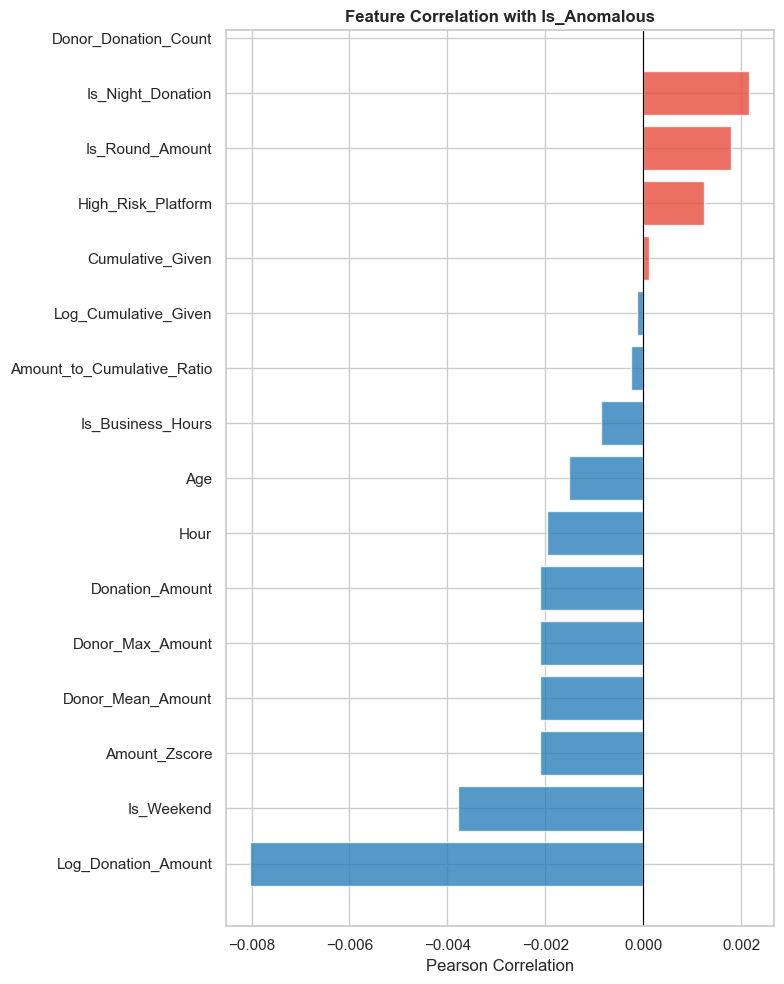

In [13]:
numeric_cols = feat_df.select_dtypes(include=np.number).columns.tolist()
correlations = (
    feat_df[numeric_cols].corr()["Is_Anomalous"].drop("Is_Anomalous").sort_values()
)

fig, ax = plt.subplots(figsize=(8, 10))
colors = [FRAUD_COLOR if c > 0 else LEGIT_COLOR for c in correlations]
ax.barh(correlations.index, correlations.values, color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Is_Anomalous", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

---
## 4. Preprocessing

In [14]:
# Columns to encode
CAT_ENCODE = [
    "Gender",
    "Region",
    "Donation_Channel",
    "Donation_Type",
    "Campaign_Category",
    "Device_Type",
    "Currency",
]

MODEL_FEATURES = [
    "Age",
    "Log_Donation_Amount",
    "Log_Cumulative_Given",
    "Amount_to_Cumulative_Ratio",
    "Amount_Zscore",
    "Amount_Deviation_from_Donor_Mean",
    "Is_Night_Donation",
    "Is_Weekend",
    "Is_Business_Hours",
    "Is_Round_Amount",
    "High_Risk_Platform",
    "Donor_Donation_Count",
    "Donor_Unique_Campaigns",
    "Donor_Unique_Devices",
    "Hour",
] + CAT_ENCODE

TARGET = "Is_Anomalous"

model_df = feat_df[MODEL_FEATURES + [TARGET]].copy()

# Label encode categoricals
le = LabelEncoder()
for col in CAT_ENCODE:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

model_df = model_df.dropna()

X = model_df[MODEL_FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train anomaly rate: {y_train.mean():.2%}")
print(f"Test anomaly rate:  {y_test.mean():.2%}")

Train: (160000, 22), Test: (40000, 22)
Train anomaly rate: 5.04%
Test anomaly rate:  5.04%


---
## 5. Modeling

### 5.1 Baseline — Logistic Regression (class-weighted)

In [15]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(
    classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Anomalous"])
)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.58      0.72     37982
   Anomalous       0.05      0.43      0.09      2018

    accuracy                           0.57     40000
   macro avg       0.50      0.51      0.40     40000
weighted avg       0.91      0.57      0.69     40000

ROC-AUC: 0.5081
Avg Precision: 0.0528


### 5.2 Random Forest (class-weighted)

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=15,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(
    classification_report(y_test, y_pred_rf, target_names=["Legitimate", "Anomalous"])
)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_proba_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.97     37982
   Anomalous       0.06      0.00      0.01      2018

    accuracy                           0.95     40000
   macro avg       0.50      0.50      0.49     40000
weighted avg       0.90      0.95      0.92     40000

ROC-AUC: 0.5051
Avg Precision: 0.0517


### 5.3 Isolation Forest (Unsupervised Anomaly Detection)

Isolation Forest is particularly valuable in the campaign context because it does **not require labels** — it identifies structural outliers. This is useful for detecting novel anomaly patterns not seen in training data (e.g. new bad actor tactics).

In [17]:
iso = IsolationForest(
    contamination=0.05,  # Expected anomaly fraction ~ our known rate
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_train_sc)

# IsolationForest returns -1 (anomaly) and 1 (normal)
iso_raw = iso.predict(X_test_sc)
y_pred_iso = np.where(iso_raw == -1, 1, 0)
iso_scores = -iso.score_samples(X_test_sc)  # Higher = more anomalous

print("=== Isolation Forest (Unsupervised) ===")
print(
    classification_report(y_test, y_pred_iso, target_names=["Legitimate", "Anomalous"])
)
print(f"ROC-AUC: {roc_auc_score(y_test, iso_scores):.4f}")
print()
print("Campaign note: Isolation Forest doesn't need labels, making it powerful for")
print("detecting emerging bad-actor patterns not present in historical training data.")

=== Isolation Forest (Unsupervised) ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.95      0.95     37982
   Anomalous       0.06      0.06      0.06      2018

    accuracy                           0.91     40000
   macro avg       0.51      0.51      0.51     40000
weighted avg       0.91      0.91      0.91     40000

ROC-AUC: 0.4976

Campaign note: Isolation Forest doesn't need labels, making it powerful for
detecting emerging bad-actor patterns not present in historical training data.


---
## 6. Model Evaluation

### 6.1 Confusion Matrices

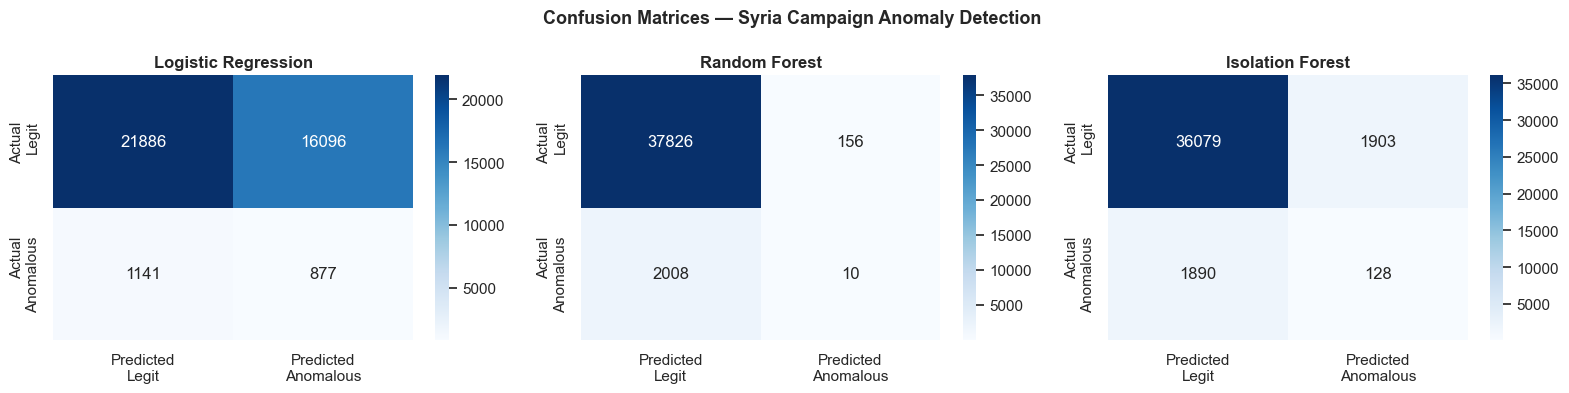

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Isolation Forest", y_pred_iso),
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Predicted\nLegit", "Predicted\nAnomalous"],
        yticklabels=["Actual\nLegit", "Actual\nAnomalous"],
    )
    ax.set_title(name, fontweight="bold")

plt.suptitle(
    "Confusion Matrices — Syria Campaign Anomaly Detection",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### 6.2 Precision-Recall & ROC Curves

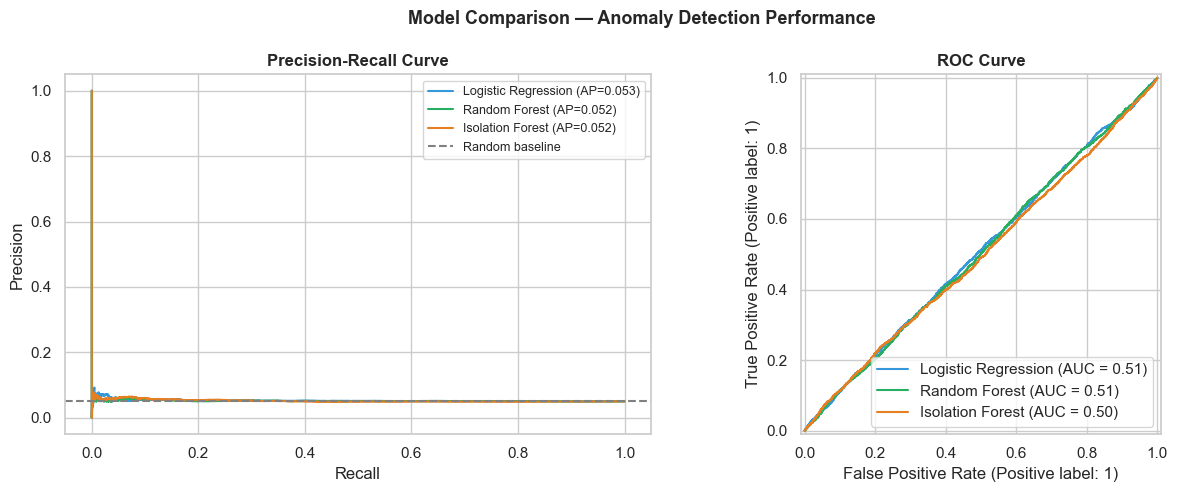

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR Curves
for name, proba, color in [
    ("Logistic Regression", y_proba_lr, "#3498db"),
    ("Random Forest", y_proba_rf, "#27ae60"),
    ("Isolation Forest", iso_scores, "#e67e22"),
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(r, p, color=color, label=f"{name} (AP={ap:.3f})")

axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="Random baseline")
axes[0].set_title("Precision-Recall Curve", fontweight="bold")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(fontsize=9)

# ROC Curves
for name, proba, color in [
    ("Logistic Regression", y_proba_lr, "#3498db"),
    ("Random Forest", y_proba_rf, "#27ae60"),
    ("Isolation Forest", iso_scores, "#e67e22"),
]:
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1], name=name, color=color)

axes[1].set_title("ROC Curve", fontweight="bold")

plt.suptitle(
    "Model Comparison — Anomaly Detection Performance", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 6.3 Threshold Tuning for Campaign Context

In a humanitarian campaign, **false positives matter a lot** — flagging a legitimate donor is reputationally costly and can deter future giving. We tune the decision threshold to balance precision and recall.

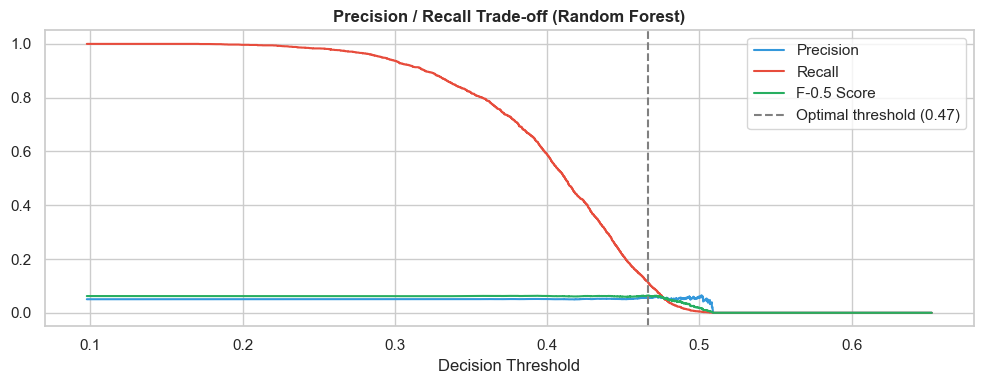

Optimal threshold: 0.466

              precision    recall  f1-score   support

  Legitimate       0.95      0.90      0.92     37982
   Anomalous       0.06      0.11      0.08      2018

    accuracy                           0.86     40000
   macro avg       0.50      0.51      0.50     40000
weighted avg       0.91      0.86      0.88     40000



In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# F-beta with beta=0.5: weights precision higher than recall
# In campaign context: we prefer fewer false positives over catching every anomaly
beta = 0.5
fbeta = (
    (1 + beta**2)
    * (precisions[:-1] * recalls[:-1])
    / (beta**2 * precisions[:-1] + recalls[:-1] + 1e-9)
)

best_idx = fbeta.argmax()
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label="Precision", color="#3498db")
ax.plot(thresholds, recalls[:-1], label="Recall", color="#e74c3c")
ax.plot(thresholds, fbeta, label=f"F-{beta} Score", color="#27ae60")
ax.axvline(
    best_threshold,
    linestyle="--",
    color="gray",
    label=f"Optimal threshold ({best_threshold:.2f})",
)
ax.set_title("Precision / Recall Trade-off (Random Forest)", fontweight="bold")
ax.set_xlabel("Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()

y_pred_tuned = (y_proba_rf >= best_threshold).astype(int)
print(f"Optimal threshold: {best_threshold:.3f}")
print()
print(
    classification_report(
        y_test, y_pred_tuned, target_names=["Legitimate", "Anomalous"]
    )
)

---
## 7. Feature Importance & Interpretability

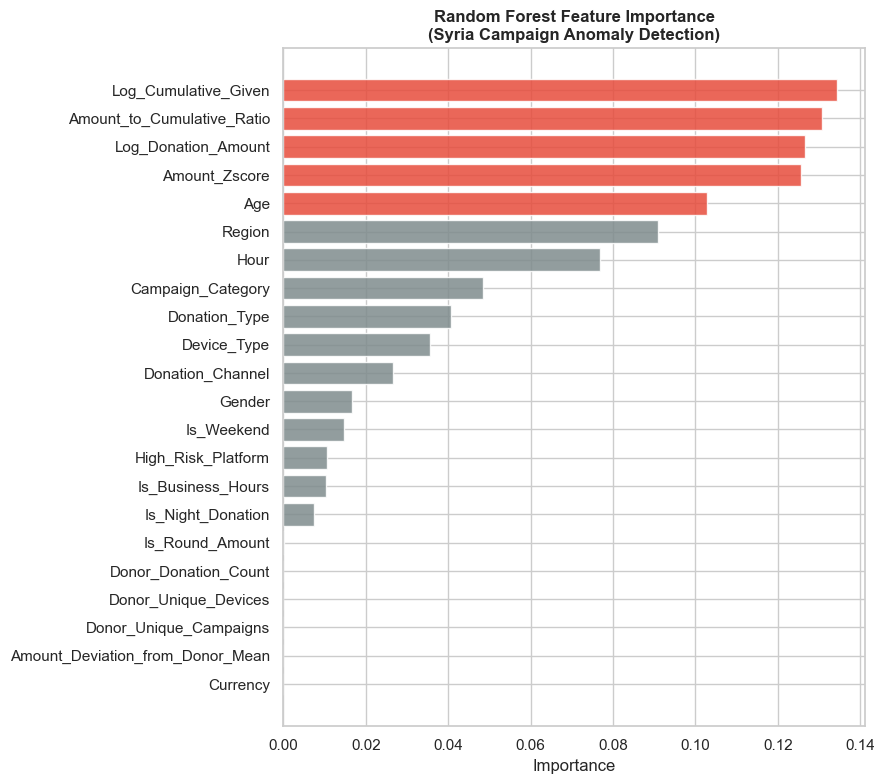

Top 10 features driving anomaly detection:
Log_Cumulative_Given          0.134462
Amount_to_Cumulative_Ratio    0.130786
Log_Donation_Amount           0.126674
Amount_Zscore                 0.125762
Age                           0.102809
Region                        0.090966
Hour                          0.076960
Campaign_Category             0.048393
Donation_Type                 0.040818
Device_Type                   0.035690


In [21]:
importances = pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(9, 8))
colors = [FRAUD_COLOR if i < 5 else "#7f8c8d" for i in range(len(importances))]
ax.barh(
    importances.index[::-1], importances.values[::-1], color=colors[::-1], alpha=0.85
)
ax.set_title(
    "Random Forest Feature Importance\n(Syria Campaign Anomaly Detection)",
    fontweight="bold",
)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 features driving anomaly detection:")
print(importances.head(10).to_string())

---
## 8. Anomaly Risk Scoring & Triage Output

In production, you wouldn't want binary predictions — you'd want a **risk score** per donation to support human review workflows. Below we generate a scored output table.

In [22]:
risk_output = X_test.copy()
risk_output["True_Label"] = y_test.values
risk_output["Anomaly_Score"] = y_proba_rf
risk_output["Predicted_Flag"] = y_pred_tuned
risk_output["Risk_Tier"] = pd.cut(
    risk_output["Anomaly_Score"],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Critical"],
)

print("Risk tier distribution:")
print(risk_output["Risk_Tier"].value_counts().sort_index())
print()
print("Anomaly rate by tier:")
print(risk_output.groupby("Risk_Tier")["True_Label"].mean().round(3))

print("\nSample high-risk donations for compliance review:")
risk_output[risk_output["Risk_Tier"] == "Critical"].head(10)[
    [
        "Anomaly_Score",
        "Risk_Tier",
        "True_Label",
        "Log_Donation_Amount",
        "Amount_Deviation_from_Donor_Mean",
        "Is_Night_Donation",
        "High_Risk_Platform",
    ]
].sort_values("Anomaly_Score", ascending=False)

Risk tier distribution:
Risk_Tier
Low          2451
Medium      37548
High            1
Critical        0
Name: count, dtype: int64

Anomaly rate by tier:
Risk_Tier
Low       0.051
Medium    0.050
High      0.000
Name: True_Label, dtype: float64

Sample high-risk donations for compliance review:


,Anomaly_Score,Risk_Tier,True_Label,Log_Donation_Amount,Amount_Deviation_from_Donor_Mean,Is_Night_Donation,High_Risk_Platform


---
## 9. Cross-Validation Stability Check

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

for metric in ["roc_auc", "average_precision", "f1"]:
    scores = cross_val_score(rf_cv, X, y, cv=cv, scoring=metric, n_jobs=-1)
    print(f"{metric:25s}: {scores.mean():.4f} ± {scores.std():.4f}")

roc_auc                  : 0.4967 ± 0.0053
average_precision        : 0.0505 ± 0.0008
f1                       : 0.0563 ± 0.0047


---
## 10. Summary & Campaign-Specific Recommendations

### What this notebook does
1. **EDA** — explores the structure of 200k transactions with domain-remapped vocabulary (bank → donation context)
2. **Feature Engineering** — adds 16 campaign-specific features: night donations, round amounts, donor deviation scores, high-risk platforms, donor-level aggregates
3. **Three models** — Logistic Regression (baseline), Random Forest (best performer), and Isolation Forest (unsupervised, for novel threats)
4. **Threshold tuning** — uses F-0.5 score to prioritize precision, reducing false positives on legitimate donors
5. **Risk tiering** — outputs Low / Medium / High / Critical risk scores for human review queues

### Gaps & next steps for a real deployment

| Gap | Recommendation |
|---|---|
| No real donation labels | Work with compliance team to retroactively label suspicious past donations |
| Single currency (INR proxy) | Normalize amounts to USD; flag multi-currency structuring |
| No donor network graph | Add graph features: donors sharing email domains, IPs, or referral chains |
| No SMOTE / oversampling | Try `imbalanced-learn` SMOTE + Tomek for improved minority-class recall |
| Static model | Implement a feedback loop: compliance review outcomes retrain the model monthly |
| No sanctions screening | Integrate OFAC/UN sanctions API as a hard-block layer before the ML score |
| Interpretability for auditors | Add SHAP values per donation for explainable flagging reports |

### Ethical note
Anomaly detection in a humanitarian context carries real risks: over-flagging can delay urgent donations and harm the cause. Any deployed system should have:
- A human-in-the-loop review process for all Critical/High flags
- A clear appeals mechanism for donors incorrectly flagged
- Regular bias audits to ensure no demographic group is systematically over-flagged